# Loop of ERA5 low cloud cover (lcc) for 2023-10-12 
## Overlaid with PIV divergence from satellite

Remarkable sense that the wave is present, and even in the right phase! 

This would I guess be because the source (imbalanced advection of momentum effects) in vigorous midlatitude synoptic weather is resolved and correctly timed in ERA5 from the history of midlatitude state data assimilation. Not because the wave itself is somehow observed and ingested and assimilated. But its long dimension indicates that the source is synoptic in scale, even though its short dimension is narrow, just a few gridpoints wide. 

The PIV divergence displayed here is from a vector velocity field from 40-pixel tiles of 30-pixel overlap in OpenPIV, using as input the half-hourly infrared data from GOES-16 interpolated to a 0.04 degree grid. The divergence field is lightly smoothed with a rolling mean filter (3 time levels, 2 lat-lon gridboxes) for clarity, and sampled hourly to match the ERA5 data interval. Contour interval can be read from the code into the caption wherever a final figure is used. 


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from openpiv import pyprocess, preprocess, validation, filters, piv
import scipy.signal
from scipy.ndimage import gaussian_filter as smoo 
from scipy import ndimage as ndi
from matplotlib.animation import FuncAnimation, writers
from matplotlib import animation
from IPython.display import display, HTML
from matplotlib.animation import PillowWriter
from pathlib import Path
from scipy.ndimage import uniform_filter

In [2]:
# PIVdiv on top of ERA5 clouds 

dsp = xr.open_dataset('/Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/PIV_outputs/2023-10-12_first_attempts/IR_2023_10_12.PIVoutput_40_30.nc')
dsp

<xarray.Dataset> Size: 37MB
Dimensions:       (time: 47, latitude: 109, longitude: 147)
Coordinates:
  * latitude      (latitude) float32 436B 9.14 8.74 8.34 ... -33.66 -34.06
  * longitude     (longitude) float32 588B -129.1 -128.7 ... -71.14 -70.74
  * time          (time) datetime64[ns] 376B 2023-10-12T00:15:00 ... 2023-10-...
Data variables:
    u             (time, latitude, longitude) float64 6MB ...
    v             (time, latitude, longitude) float64 6MB ...
    sig2noise     (time, latitude, longitude) float64 6MB ...
    u2            (time, latitude, longitude) float64 6MB ...
    v2            (time, latitude, longitude) float64 6MB ...
    invalid_mask  (time, latitude, longitude) bool 753kB ...
    divergence    (time, latitude, longitude) float64 6MB ...
Attributes:
    window_size:       40
    overlap:           30
    search_area_size:  40
    dt_seconds:        1800.0
    source:            OpenPIV extended_search_area_piv
    valid_fraction:    0.45884041690070526

In [3]:
dse = xr.open_dataset('/Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/2023_Oct11-14_ERA5_2Dfields/data_stream-oper_stepType-instant.nc')
dse

<xarray.Dataset> Size: 113MB
Dimensions:     (valid_time: 96, latitude: 261, longitude: 281)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 768B 2023-10-11 ... 2023-10-14T23...
  * latitude    (latitude) float64 2kB 10.0 9.75 9.5 9.25 ... -54.5 -54.75 -55.0
  * longitude   (longitude) float64 2kB -140.0 -139.8 -139.5 ... -70.25 -70.0
    expver      (valid_time) <U4 2kB ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 28MB ...
    aluvd       (valid_time, latitude, longitude) float32 28MB ...
    lcc         (valid_time, latitude, longitude) float32 28MB ...
    blh         (valid_time, latitude, longitude) float32 28MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-12-16T18:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [81]:
# Time=smoothed div on lcc animation 

# SW to NE cross section: indicate this central transect and its averaging band on the animation 
lat_ne, lon_ne = -11, -88 
lat_sw, lon_sw = -23, -97 
XSEC_WIDTH = 500 # km 

# compute offset in degrees for the band edges
dlat, dlon = lat_ne - lat_sw, lon_ne - lon_sw
length_deg = np.sqrt(dlat**2 + dlon**2)
perp_lat =  (dlon / length_deg) * (XSEC_WIDTH / 111.32)
perp_lon = -(dlat / length_deg) * (XSEC_WIDTH / 111.32)


# lcc 
lcc = dse.lcc.sel(valid_time=slice('2023-10-12-T12','2023-10-12-T23'), latitude=slice(-11, -24), longitude=slice(-102,-88))

# make animation set 
data = [(lcc.isel(valid_time=t)) for t in range(len(lcc.valid_time))]

# Plot title 
titlestring = "E5 low cloud cover, "

fig, ax = plt.subplots()
ani = animation.FuncAnimation(fig, lambda f: (ax.clear(),
                                              data[f].plot(ax=ax, add_colorbar=False, vmin=0, vmax=1, cmap='Greys_r'),
                                              ax.plot([lon_sw, lon_ne], [lat_sw, lat_ne], 'w-'),
                                              ax.plot([lon_sw-perp_lon, lon_ne-perp_lon], [lat_sw-perp_lat, lat_ne-perp_lat], 'r--'),
                                              ax.plot([lon_sw+perp_lon, lon_ne+perp_lon], [lat_sw+perp_lat, lat_ne+perp_lat], 'r--'),
                                              ax.set_title(titlestring + ax.get_title())),
                                              frames=len(data), interval=100)

ani.save('/Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/PIV_outputs/ERA5lccanimation.gif', writer='pillow')

display(HTML(ani.to_jshtml()))
plt.close()

In [112]:
#data = [(lcc.isel(valid_time=t)) for t in range(len(lcc.valid_time))]

# smooth div in time, lat, lon, lightly 
xytsmoodiv = dsp.divergence.rolling(time=3, latitude=2, longitude=2, center=True).mean()
data = [xytsmoodiv.isel(time=t) for t in range(len(xytsmoodiv.time)-3)]

# Data sets for overlay: 
data = [lcc.isel(valid_time=t) for t in range(lcc.sizes['valid_time'])]
div  = [xytsmoodiv.sel(time=t, method='nearest').sel(latitude=slice(-12,-23), longitude=slice(-102,-88)) 
        for t in lcc.valid_time.values]

# Make div a da with same-time-lat-lon shape as lcc 
div_da = xr.concat(div, dim=lcc.valid_time)
div_da = div_da.interp(latitude=lcc.latitude, longitude=lcc.longitude)


titlestring = "E5 low cloud + sat. PIV div, "

fig, ax = plt.subplots()
ani = animation.FuncAnimation(fig, lambda f: (ax.clear(),
                                              data[f].plot(ax=ax, add_colorbar=False, vmin=0, vmax=1, cmap='Greys_r'),
                                              div[f].plot.contour(ax=ax, levels=np.linspace(-0.2e-4, 0.2e-4, 8)),
                                              ax.plot([lon_sw, lon_ne], [lat_sw, lat_ne], 'w-'),
                                              ax.plot([lon_sw-perp_lon, lon_ne-perp_lon], [lat_sw-perp_lat, lat_ne-perp_lat], 'r--'),
                                              ax.plot([lon_sw+perp_lon, lon_ne+perp_lon], [lat_sw+perp_lat, lat_ne+perp_lat], 'r--'),                                              ax.set_title(titlestring + ax.get_title())),
                                              frames=len(data), interval=300)

ani.save('/Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/PIV_outputs/ERA5lccanimation+PIVdiv.gif', writer='pillow')

display(HTML(ani.to_jshtml()))
plt.close()

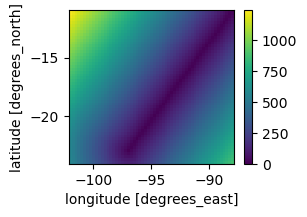

In [113]:
# Mean transect construction: step 1, compute array of distances from diagonal line 

from scipy.spatial.distance import cdist

# --- define transect line as array of (lat,lon) points -----------------
n = 200
lat_line = np.linspace(lat_sw, lat_ne, n)
lon_line = np.linspace(lon_sw, lon_ne, n)
line_pts = np.column_stack([lat_line, lon_line])

# --- distance from every grid point to nearest point on the line -------
LAT2D, LON2D = np.meshgrid(lcc.latitude, lcc.longitude, indexing='ij')
grid_pts = np.column_stack([LAT2D.ravel(), LON2D.ravel()])

# minimum distance to any point on the line, in degrees (approx)
dist_to_line = cdist(grid_pts, line_pts).min(axis=1).reshape(LAT2D.shape)
dist_km = dist_to_line * 111.32   # rough degrees→km

# LCC dist_da
dist_da = xr.DataArray(dist_km, dims=['latitude','longitude'],
                        coords={'latitude': lcc.latitude, 'longitude': lcc.longitude})

dist_da.plot(size=2);

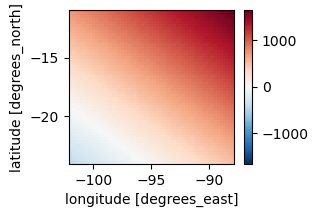

In [114]:
# Step 3: TO bin by along-line distince index, we need a 2D array of that distance

# unit vector along transect
dlat, dlon = lat_ne - lat_sw, lon_ne - lon_sw
length = np.sqrt(dlat**2 + dlon**2)
ulat, ulon = dlat/length, dlon/length

# signed along-transect distance from SW end (degrees)
along = ((LAT2D - lat_sw)*ulat + (LON2D - lon_sw)*ulon) * 111.32  # km

# LCC along_da
along_da = xr.DataArray(along, dims=['latitude','longitude'],
                         coords={'latitude': lcc.latitude, 'longitude': lcc.longitude})
# DIV along_da2: not so easy, "along" is also specific to lcc data grid. Sigh. 
# along_da2 = xr.DataArray(along, dims=['latitude','longitude'],
#                          coords={'latitude': div_da.latitude, 'longitude': div_da.longitude})

along_da.plot(size=2);

In [115]:
# Ready to bin-average by distance ALONG, after masking for distance ACROSS 

# Mask lcc for the band 
lccband = lcc.where(dist_da < XSEC_WIDTH)   # mask for all points within 100km of line

divband = div_da.where(dist_da < XSEC_WIDTH)   # mask for all points within 100km of line


# 80 bins for averaging the lcc field (masked in a belt), bins are by distance along the transect
bins = np.linspace(0, float(along_da.where(dist_da < XSEC_WIDTH).max()), 80)
labels = 0.5*(bins[:-1] + bins[1:])

groupedlcc = (lccband.assign_coords(along=along_da)
               .groupby_bins('along', bins=bins, labels=labels)
               .mean())
groupeddiv = (divband.assign_coords(along=along_da)
               .groupby_bins('along', bins=bins, labels=labels)
               .mean())

lon_bins = np.linspace(lon_sw, lon_ne, len(bins)-1)

grouped = xr.Dataset({'lcc': groupedlcc, 'div': groupeddiv})
grouped['along_bins'] = lon_bins
grouped['along_bins'].attrs['long_name'] = 'Longitude'

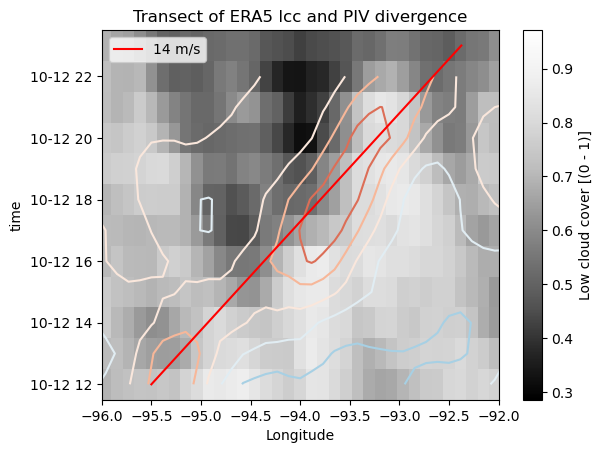

In [124]:
grouped.lcc.plot(cmap='Greys_r');
grouped.div.plot.contour(levels=np.linspace(-0.2e-4, 0.2e-4, 10));

plt.xlim([-96, -92]);

# Annotation line for 14 m/s 
c_line = 14 # m/s

# fraction of motion that projects onto longitude axis
dlat, dlon = lat_ne - lat_sw, lon_ne - lon_sw
length_deg = np.sqrt(dlat**2 + dlon**2)
lon_fraction = dlon / length_deg   # how much of along-transect is in lon direction

# 14 m/s line 
cos_lat = np.cos(np.radians(0.5*(lat_sw + lat_ne)))
speed_deglon_per_sec = c_line / (111320 * cos_lat) * lon_fraction

# draw the line anchored at a reference point (x0_ref, t0_ref)
t0_ref = grouped.valid_time.values[0]
t_secs = (grouped.valid_time.values - t0_ref) / np.timedelta64(1, 's')
lon_ref = -95.5   # adjust anchor longitude

ax = plt.gca()
ax.plot(lon_ref + t_secs * speed_deglon_per_sec, grouped.valid_time.values, 'r-', label='14 m/s')
ax.set_title('Transect of ERA5 lcc and PIV divergence')
ax.legend();